✅ Eye templates directory created at /content/eye_templates/
👁️  REAL-TIME EYE DETECTION WITH LANDMARK VISUALIZATION

📋 Choose capture method:
1. Webcam Capture (Real-time with eye landmarks)
2. Upload Image File
Enter your choice (1 or 2): 1

🚀 Starting webcam capture with real-time eye landmark visualization...
   💚 Green lines: Eye contours
   🔴 Red dots: Individual landmarks
   🔵 Blue boxes: Captured eye regions


📸 INSTRUCTIONS:
1. Position your face in the camera - make sure it's well lit
2. Look directly at the camera
3. You should see green lines around your eyes in real-time
4. Click 'Capture Eyes' button when ready
5. Blue bounding boxes will show the captured eye regions
6. Click 'Stop' when done

⏳ Waiting for capture...

✅ CELL 1 COMPLETED!

📝 NEXT STEPS:
1. Make sure you see 'SUCCESS! Captured and saved X eye(s)' message
2. Check that eye images with landmarks are displayed above
3. Run Cell 2 for iris segmentation

💾 Your eye templates are safely saved in Colab file system!
   Location: /content/eye_templates/


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


✅ Saved 2 eye template(s) to /content/eye_templates
🎉 SUCCESS! Captured and saved 2 eye(s)


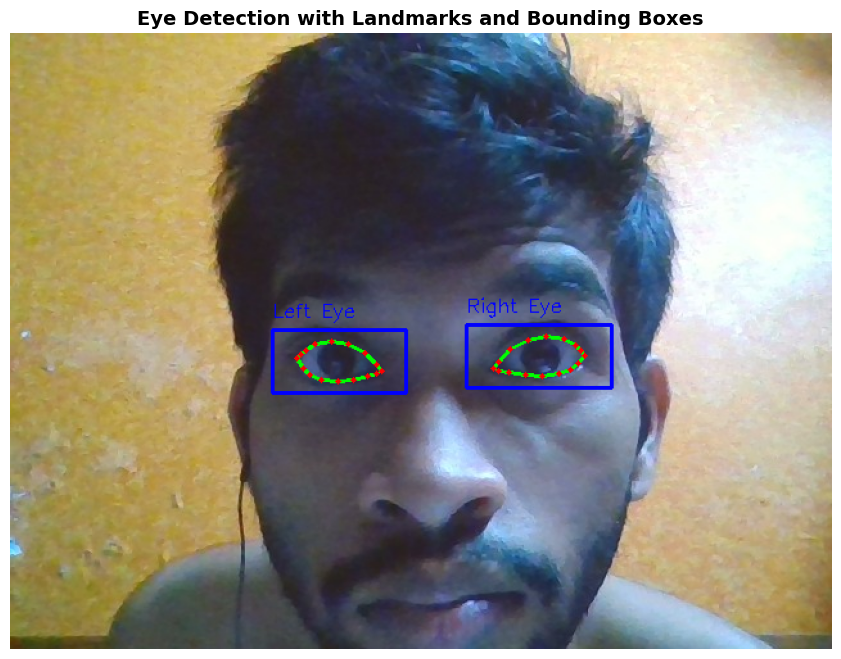

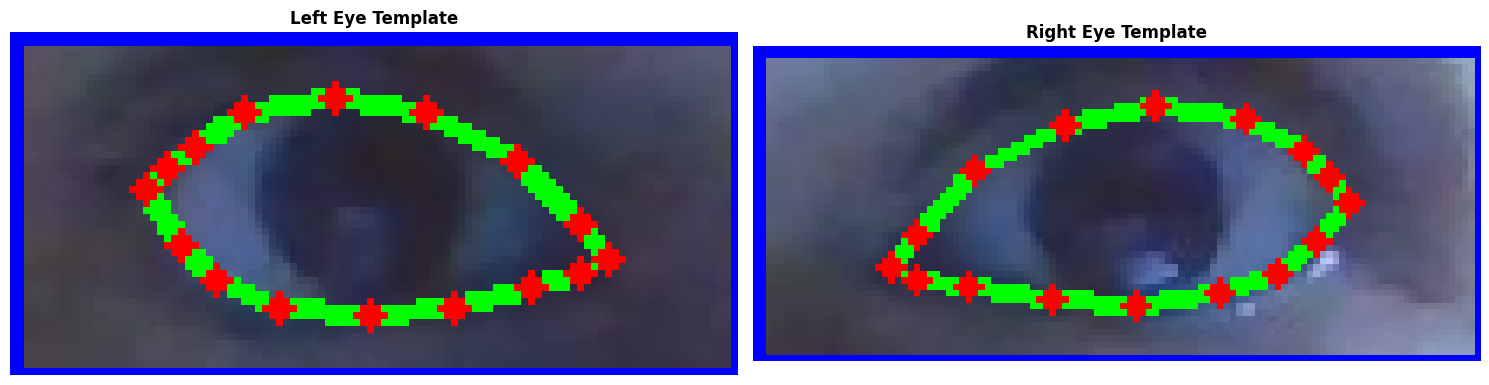


📁 Eye templates saved to Colab file system:
   Location: /content/eye_templates/
   - eye_left_1.png
   - eye_right_2.png
🛑 Webcam stopped


In [ ]:
# Install required packages
!pip install opencv-python-headless mediapipe numpy Pillow

import cv2
import mediapipe as mp
import numpy as np
from PIL import Image
import os
import json
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

%matplotlib inline

# Create directory for saving eye templates
!mkdir -p /content/eye_templates

print("✅ Eye templates directory created at /content/eye_templates/")

# Initialize MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

# Define eye regions (MediaPipe landmarks)
LEFT_EYE_INDICES = [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246]
RIGHT_EYE_INDICES = [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398]

# Define connections for drawing eye contours
LEFT_EYE_CONNECTIONS = [
    (33, 7), (7, 163), (163, 144), (144, 145), (145, 153),
    (153, 154), (154, 155), (155, 133), (133, 173), (173, 157),
    (157, 158), (158, 159), (159, 160), (160, 161), (161, 246),
    (246, 33)
]

RIGHT_EYE_CONNECTIONS = [
    (362, 382), (382, 381), (381, 380), (380, 374), (374, 373),
    (373, 390), (390, 249), (249, 263), (263, 466), (466, 388),
    (388, 387), (387, 386), (386, 385), (385, 384), (384, 398),
    (398, 362)
]

class EyeDetector:
    def __init__(self):
        self.face_mesh = mp_face_mesh.FaceMesh(
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )

    def draw_eye_landmarks(self, image, landmarks, eye_indices, connections, color=(0, 255, 0), thickness=2):
        """Draw lines connecting eye landmarks"""
        h, w = image.shape[:2]

        # Draw connecting lines
        for start_idx, end_idx in connections:
            if start_idx < len(landmarks.landmark) and end_idx < len(landmarks.landmark):
                start_point = landmarks.landmark[start_idx]
                end_point = landmarks.landmark[end_idx]

                start_x = int(start_point.x * w)
                start_y = int(start_point.y * h)
                end_x = int(end_point.x * w)
                end_y = int(end_point.y * h)

                cv2.line(image, (start_x, start_y), (end_x, end_y), color, thickness)

        # Draw landmark points
        for idx in eye_indices:
            if idx < len(landmarks.landmark):
                landmark = landmarks.landmark[idx]
                x = int(landmark.x * w)
                y = int(landmark.y * h)
                cv2.circle(image, (x, y), 2, (0, 0, 255), -1)  # Red dots for landmarks

    def get_eye_roi(self, landmarks, eye_indices, image_shape):
        """Extract eye region of interest"""
        h, w = image_shape[:2]
        eye_points = []

        for idx in eye_indices:
            if idx < len(landmarks.landmark):
                landmark = landmarks.landmark[idx]
                x = int(landmark.x * w)
                y = int(landmark.y * h)
                eye_points.append((x, y))

        if len(eye_points) == 0:
            return None

        # Get bounding box with padding
        x_coords = [p[0] for p in eye_points]
        y_coords = [p[1] for p in eye_points]

        x_min, x_max = min(x_coords), max(x_coords)
        y_min, y_max = min(y_coords), max(y_coords)

        # Add padding
        padding_x = int((x_max - x_min) * 0.3)
        padding_y = int((y_max - y_min) * 0.3)

        x_min = max(0, x_min - padding_x)
        x_max = min(w, x_max + padding_x)
        y_min = max(0, y_min - padding_y)
        y_max = min(h, y_max + padding_y)

        if x_max <= x_min or y_max <= y_min:
            return None

        return (x_min, y_min, x_max, y_max)

    def process_frame(self, image, draw_landmarks=True):
        """Process frame and detect eyes with optional landmark drawing"""
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = self.face_mesh.process(rgb_image)

        eye_regions = []

        if results.multi_face_landmarks:
            for face_landmarks in results.multi_face_landmarks:
                # Draw eye landmarks if requested
                if draw_landmarks:
                    self.draw_eye_landmarks(image, face_landmarks, LEFT_EYE_INDICES, LEFT_EYE_CONNECTIONS, (0, 255, 0), 2)
                    self.draw_eye_landmarks(image, face_landmarks, RIGHT_EYE_INDICES, RIGHT_EYE_CONNECTIONS, (0, 255, 0), 2)

                # Get left eye
                left_eye_roi = self.get_eye_roi(face_landmarks, LEFT_EYE_INDICES, image.shape)
                if left_eye_roi:
                    x_min, y_min, x_max, y_max = left_eye_roi
                    if (y_max - y_min) > 10 and (x_max - x_min) > 10:
                        left_eye = image[y_min:y_max, x_min:x_max]
                        eye_regions.append(('left', left_eye, left_eye_roi))
                        # Draw bounding box
                        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
                        cv2.putText(image, 'Left Eye', (x_min, y_min-10),
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

                # Get right eye
                right_eye_roi = self.get_eye_roi(face_landmarks, RIGHT_EYE_INDICES, image.shape)
                if right_eye_roi:
                    x_min, y_min, x_max, y_max = right_eye_roi
                    if (y_max - y_min) > 10 and (x_max - x_min) > 10:
                        right_eye = image[y_min:y_max, x_min:x_max]
                        eye_regions.append(('right', right_eye, right_eye_roi))
                        # Draw bounding box
                        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
                        cv2.putText(image, 'Right Eye', (x_min, y_min-10),
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

        return eye_regions

def save_eye_templates(eye_regions, save_dir="/content/eye_templates"):
    """Save eye templates to Colab file system"""
    if not eye_regions:
        return False

    # Clear previous templates
    if os.path.exists(save_dir):
        for file in os.listdir(save_dir):
            os.remove(os.path.join(save_dir, file))

    template_info = []

    for i, (eye_type, eye_img, bbox) in enumerate(eye_regions):
        # Save eye image
        filename = f"eye_{eye_type}_{i+1}.png"
        filepath = os.path.join(save_dir, filename)

        # Convert BGR to RGB for saving
        eye_rgb = cv2.cvtColor(eye_img, cv2.COLOR_BGR2RGB)
        cv2.imwrite(filepath, eye_rgb)

        # Store template info
        template_info.append({
            'filename': filename,
            'type': eye_type,
            'bbox': bbox,
            'shape': eye_img.shape
        })

    # Save template information as JSON
    info_path = os.path.join(save_dir, "templates_info.json")
    with open(info_path, 'w') as f:
        json.dump(template_info, f, indent=2)

    print(f"✅ Saved {len(eye_regions)} eye template(s) to {save_dir}")
    return True

def capture_eyes_webcam():
    """Capture eyes using webcam with JavaScript and real-time landmark display"""
    from IPython.display import HTML, display
    from google.colab.output import eval_js
    from base64 import b64decode
    import io
    import time

    # JavaScript for webcam access with continuous preview
    VIDEO_HTML = """
    <div style="text-align: center;">
        <div style="background: linear-gradient(45deg, #ff6b6b, #4ecdc4); padding: 10px; border-radius: 10px; margin-bottom: 10px;">
            <h3 style="color: white; margin: 0;">👁️ Real-Time Eye Detection</h3>
        </div>
        <video id="video" width="640" height="480" autoplay style="border: 3px solid #4ecdc4; border-radius: 10px;"></video><br/>
        <div style="margin: 10px;">
            <button onclick="capture()" style="padding: 12px 24px; font-size: 16px; margin: 5px; background: #4ecdc4; color: white; border: none; border-radius: 5px; cursor: pointer;">
                📸 Capture Eyes
            </button>
            <button onclick="stop()" style="padding: 12px 24px; font-size: 16px; margin: 5px; background: #ff6b6b; color: white; border: none; border-radius: 5px; cursor: pointer;">
                🛑 Stop
            </button>
        </div>
        <div id="status" style="margin: 10px; padding: 10px; background: #f8f9fa; border-radius: 5px; font-size: 14px;">
            Status: Waiting for face detection...
        </div>
    </div>
    <script>
        var video = document.getElementById('video');
        var stream = null;
        var statusDiv = document.getElementById('status');

        // Access webcam
        navigator.mediaDevices.getUserMedia({ video: true })
            .then(function(s) {
                stream = s;
                video.srcObject = stream;
                statusDiv.innerHTML = "Status: ✅ Webcam active - Position your face in frame";
            })
            .catch(function(err) {
                console.log("Error: " + err);
                statusDiv.innerHTML = "Status: ❌ Cannot access webcam: " + err;
                alert("Cannot access webcam: " + err);
            });

        function capture() {
            var canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            var context = canvas.getContext('2d');
            context.drawImage(video, 0, 0);
            var data = canvas.toDataURL('image/jpeg');

            statusDiv.innerHTML = "Status: 🔍 Processing image for eye detection...";

            // Send to Python
            google.colab.kernel.invokeFunction('notebook.capture_frame', [data], {});
        }

        function stop() {
            if (stream) {
                stream.getTracks().forEach(track => track.stop());
            }
            statusDiv.innerHTML = "Status: 🛑 Webcam stopped";
            google.colab.kernel.invokeFunction('notebook.stop_capture', [], {});
        }
    </script>
    """

    display(HTML(VIDEO_HTML))

    captured_frames = []
    detector = EyeDetector()

    def capture_frame(data):
        """Handle captured frame with landmark visualization"""
        try:
            # Decode base64 image
            data = data.split(',')[1]
            binary = b64decode(data)
            image = Image.open(io.BytesIO(binary))
            frame = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

            # Create a copy for display with landmarks
            display_frame = frame.copy()

            # Process for eyes with landmark drawing
            eye_regions = detector.process_frame(display_frame, draw_landmarks=True)

            if eye_regions:
                # Save templates to file system
                success = save_eye_templates(eye_regions)
                if success:
                    print(f"🎉 SUCCESS! Captured and saved {len(eye_regions)} eye(s)")

                    # Display the frame with landmarks and bounding boxes
                    display_frame_rgb = cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)
                    plt.figure(figsize=(12, 8))
                    plt.imshow(display_frame_rgb)
                    plt.title('Eye Detection with Landmarks and Bounding Boxes', fontweight='bold', fontsize=14)
                    plt.axis('off')
                    plt.show()

                    # Display individual captured eye templates
                    fig, axes = plt.subplots(1, len(eye_regions), figsize=(15, 5))
                    if len(eye_regions) == 1:
                        axes = [axes]

                    for idx, (eye_type, eye_img, bbox) in enumerate(eye_regions):
                        eye_rgb = cv2.cvtColor(eye_img, cv2.COLOR_BGR2RGB)
                        axes[idx].imshow(eye_rgb)
                        axes[idx].set_title(f'{eye_type.capitalize()} Eye Template', fontweight='bold')
                        axes[idx].axis('off')

                    plt.tight_layout()
                    plt.show()

                    print("\n📁 Eye templates saved to Colab file system:")
                    print("   Location: /content/eye_templates/")
                    for i, (eye_type, _, _) in enumerate(eye_regions):
                        print(f"   - eye_{eye_type}_{i+1}.png")

                else:
                    print("❌ Failed to save eye templates")
            else:
                print("❌ No eyes detected. Please try again with better lighting and positioning.")
                # Show the captured frame anyway
                display_frame_rgb = cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)
                plt.figure(figsize=(10, 8))
                plt.imshow(display_frame_rgb)
                plt.title('Captured Frame - No Eyes Detected', fontweight='bold', color='red')
                plt.axis('off')
                plt.show()

        except Exception as e:
            print(f"❌ Error processing frame: {e}")

    def stop_capture():
        """Stop webcam"""
        print("🛑 Webcam stopped")

    # Register callbacks
    import google.colab
    google.colab.output.register_callback('notebook.capture_frame', capture_frame)
    google.colab.output.register_callback('notebook.stop_capture', stop_capture)

    print("📸 INSTRUCTIONS:")
    print("1. Position your face in the camera - make sure it's well lit")
    print("2. Look directly at the camera")
    print("3. You should see green lines around your eyes in real-time")
    print("4. Click 'Capture Eyes' button when ready")
    print("5. Blue bounding boxes will show the captured eye regions")
    print("6. Click 'Stop' when done")
    print("\n⏳ Waiting for capture...")

def capture_eyes_upload():
    """Capture eyes by uploading an image"""
    from google.colab import files
    import io

    print("📁 Upload an image containing clear eyes:")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No file uploaded!")
        return

    detector = EyeDetector()

    for filename in uploaded.keys():
        print(f"🔍 Processing {filename}...")

        # Read uploaded image
        image_data = uploaded[filename]
        image = Image.open(io.BytesIO(image_data))
        frame = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

        # Create copy for display
        display_frame = frame.copy()

        # Detect eyes with landmark drawing
        eye_regions = detector.process_frame(display_frame, draw_landmarks=True)

        if eye_regions:
            # Save to file system
            success = save_eye_templates(eye_regions)

            if success:
                print(f"✅ Found and saved {len(eye_regions)} eye(s) from uploaded image!")

                # Display detection results with landmarks
                display_frame_rgb = cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)
                plt.figure(figsize=(12, 8))
                plt.imshow(display_frame_rgb)
                plt.title('Eye Detection with Landmarks and Bounding Boxes', fontweight='bold', fontsize=14)
                plt.axis('off')
                plt.show()

                # Show individual eye templates
                fig, axes = plt.subplots(1, len(eye_regions), figsize=(15, 5))
                if len(eye_regions) == 1:
                    axes = [axes]

                for idx, (eye_type, eye_img, bbox) in enumerate(eye_regions):
                    eye_rgb = cv2.cvtColor(eye_img, cv2.COLOR_BGR2RGB)
                    axes[idx].imshow(eye_rgb)
                    axes[idx].set_title(f'{eye_type.capitalize()} Eye Template', fontweight='bold')
                    axes[idx].axis('off')

                plt.tight_layout()
                plt.show()

            else:
                print("❌ Failed to save eye templates")
        else:
            print("❌ No eyes detected in the uploaded image")

# MAIN EXECUTION
print("="*70)
print("👁️  REAL-TIME EYE DETECTION WITH LANDMARK VISUALIZATION")
print("="*70)

print("\n📋 Choose capture method:")
print("1. Webcam Capture (Real-time with eye landmarks)")
print("2. Upload Image File")

choice = input("Enter your choice (1 or 2): ").strip()

if choice == "1":
    print("\n🚀 Starting webcam capture with real-time eye landmark visualization...")
    print("   💚 Green lines: Eye contours")
    print("   🔴 Red dots: Individual landmarks")
    print("   🔵 Blue boxes: Captured eye regions")
    capture_eyes_webcam()
else:
    print("\n📁 Starting image upload...")
    capture_eyes_upload()

print("\n" + "="*70)
print("✅ CELL 1 COMPLETED!")
print("="*70)
print("\n📝 NEXT STEPS:")
print("1. Make sure you see 'SUCCESS! Captured and saved X eye(s)' message")
print("2. Check that eye images with landmarks are displayed above")
print("3. Run Cell 2 for iris segmentation")
print("\n💾 Your eye templates are safely saved in Colab file system!")
print("   Location: /content/eye_templates/")

✅ Enhanced Iris Segmentation Packages Loaded!
🚀 Starting Accurate Circle Detection Iris Segmentation
📁 Loading eye templates from Colab file system...
✅ Loaded: eye_left_1.png (left eye)
✅ Loaded: eye_right_2.png (right eye)
✅ Successfully loaded 2 eye template(s)
🔧 Initializing Accurate Circle Detection Processor...

🔬 Processing with accurate circle detection...

🔍 Processing left eye with accurate circle detection...
   Step 1: Advanced Image Enhancement
   Step 2: Accurate Iris Circle Detection
   ✅ Iris detected: center=(52, 23), radius=15
   Step 3: Eyelash and Eyelid Removal
   Step 4: Accurate Pupil Circle Detection
   ✅ Pupil detected: center=(49, 27), radius=4
   Step 5: Pupil Removal and Final Mask
   Step 6: Clean Iris Extraction

🔍 Processing right eye with accurate circle detection...
   Step 1: Advanced Image Enhancement
   Step 2: Accurate Iris Circle Detection
   ✅ Iris detected: center=(58, 24), radius=15
   Step 3: Eyelash and Eyelid Removal
   Step 4: Accurate Pupil

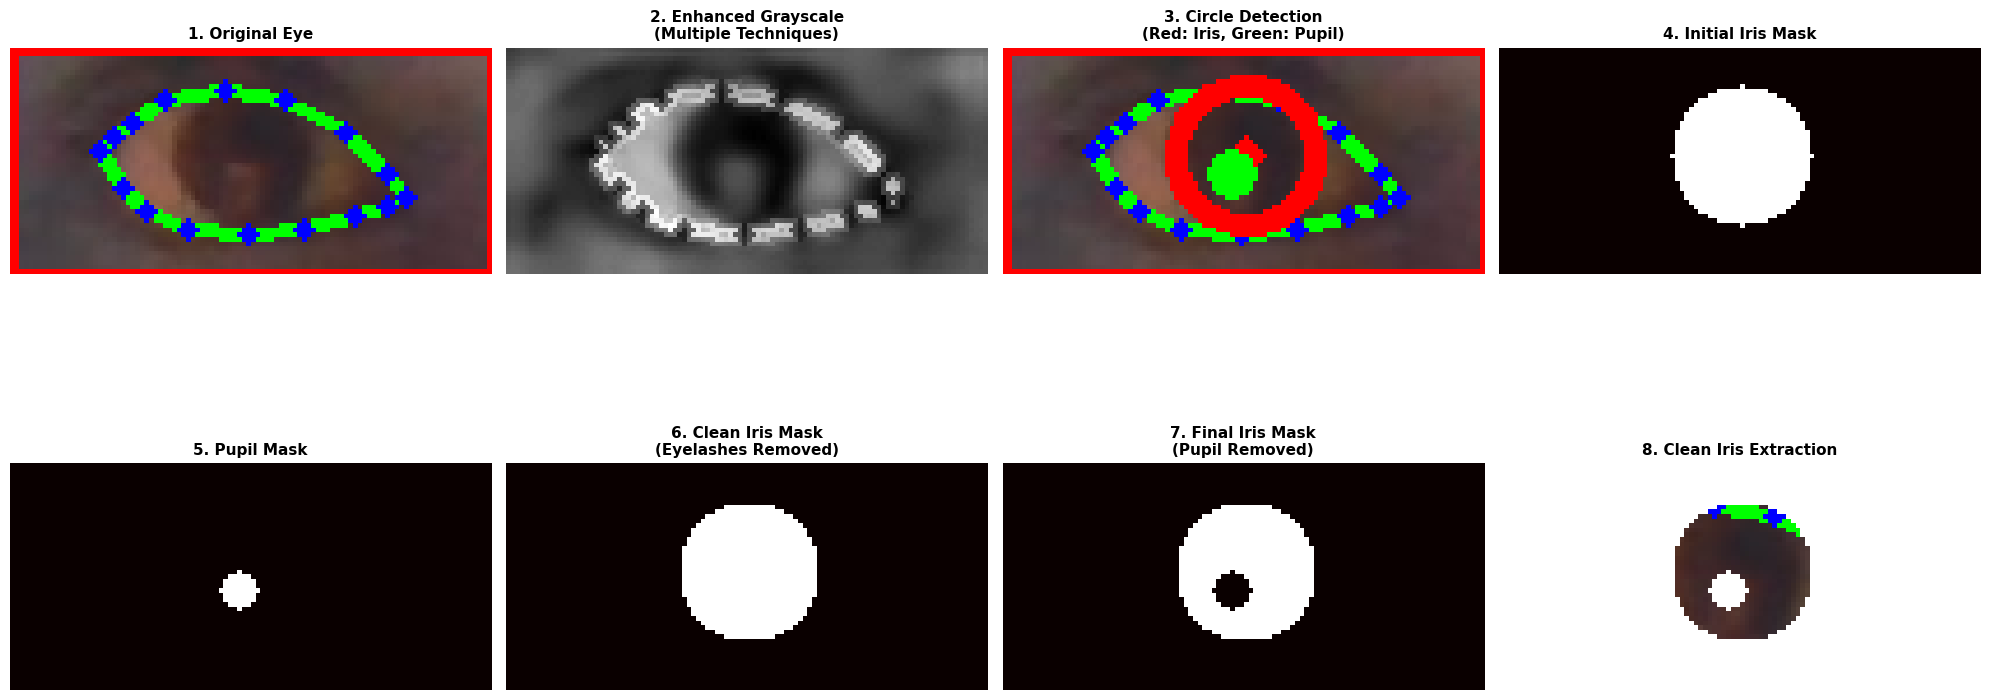


📊 IRIS DETECTION DETAILS:
   • Center: (52, 23)
   • Radius: 15 pixels
   • Area: 706 pixels
📊 PUPIL DETECTION DETAILS:
   • Center: (49, 27)
   • Radius: 4 pixels
   • Area: 50 pixels
📊 IRIS-PUPIL RELATIONSHIP:
   • Center Distance: 5.0 pixels
   • Radius Ratio: 0.27
   • Area Ratio: 0.07

🎯 ACCURATE CIRCLE DETECTION - RIGHT EYE


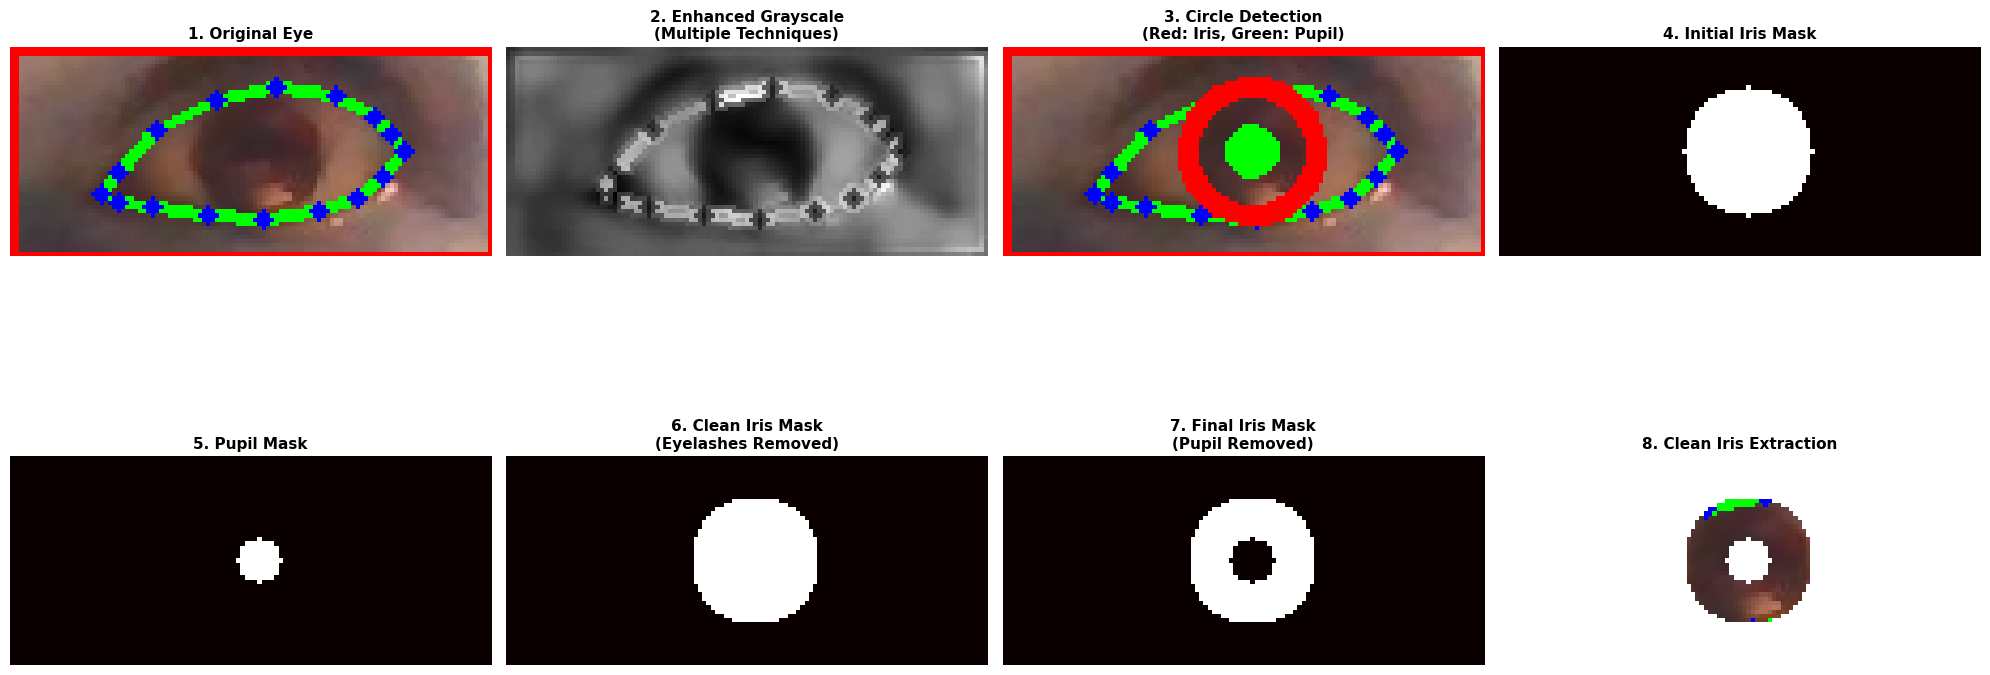


📊 IRIS DETECTION DETAILS:
   • Center: (58, 24)
   • Radius: 15 pixels
   • Area: 706 pixels
📊 PUPIL DETECTION DETAILS:
   • Center: (58, 24)
   • Radius: 5 pixels
   • Area: 78 pixels
📊 IRIS-PUPIL RELATIONSHIP:
   • Center Distance: 0.0 pixels
   • Radius Ratio: 0.33
   • Area Ratio: 0.11

💾 Saving segmented iris images...
💾 Saved segmented iris: segmented_eye_left_1.png
💾 Saved segmented iris: segmented_eye_right_2.png

✅ Successfully saved 2 segmented iris images to: /content/segmented_iris

🎉 ACCURATE IRIS SEGMENTATION COMPLETED!

💾 Results saved to 'accurate_results' variable

🔧 Available for analysis:
   • accurate_results - All results with precise circle coordinates
   • Segmented iris images saved in '/content/segmented_iris/' directory


In [ ]:
# Install required packages
!pip install opencv-python-headless scikit-image matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, morphology, measure
import os
import json

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

print("✅ Enhanced Iris Segmentation Packages Loaded!")

def load_eye_templates(templates_dir="/content/eye_templates"):
    """Load eye templates from Colab file system"""
    if not os.path.exists(templates_dir):
        print(f"❌ Templates directory not found: {templates_dir}")
        return None

    info_path = os.path.join(templates_dir, "templates_info.json")
    if not os.path.exists(info_path):
        print("❌ No template information found")
        return None

    with open(info_path, 'r') as f:
        template_info = json.load(f)

    eye_templates = []

    for info in template_info:
        filepath = os.path.join(templates_dir, info['filename'])
        if os.path.exists(filepath):
            eye_img = cv2.imread(filepath)
            if eye_img is not None:
                eye_templates.append({
                    'type': info['type'],
                    'image': eye_img,
                    'bbox': info['bbox'],
                    'filename': info['filename']
                })
                print(f"✅ Loaded: {info['filename']} ({info['type']} eye)")
            else:
                print(f"❌ Failed to load: {info['filename']}")
        else:
            print(f"❌ File not found: {info['filename']}")

    return eye_templates

class AccurateCircleProcessor:
    def __init__(self):
        print("🔧 Initializing Accurate Circle Detection Processor...")

    def enhance_image_for_circle_detection(self, eye_image):
        """Enhanced preprocessing specifically for circle detection"""
        # Convert to different color spaces
        gray = cv2.cvtColor(eye_image, cv2.COLOR_BGR2GRAY)

        # Multiple enhancement techniques
        # 1. CLAHE for contrast
        clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
        enhanced_gray = clahe.apply(gray)

        # 2. Bilateral filter to preserve edges
        bilateral = cv2.bilateralFilter(enhanced_gray, 9, 75, 75)

        # 3. Morphological gradient for edge enhancement
        kernel = np.ones((3,3), np.uint8)
        gradient = cv2.morphologyEx(bilateral, cv2.MORPH_GRADIENT, kernel)

        # 4. Combine enhancements
        final_enhanced = cv2.addWeighted(bilateral, 0.7, gradient, 0.3, 0)

        return final_enhanced, gray

    def detect_iris_circle_accurate(self, enhanced_gray, original_gray):
        """Accurate iris circle detection using multiple methods"""
        height, width = enhanced_gray.shape

        # Convert to integers for HoughCircles parameters
        height_int = int(height)
        width_int = int(width)

        # Method 1: Hough Circles with multiple parameter sets
        circles_list = []

        # Try different parameter combinations (all parameters as integers)
        param_sets = [
            {'dp': 1.1, 'minDist': height_int//2, 'param1': 100, 'param2': 30, 'minRadius': height_int//6, 'maxRadius': height_int//2},
            {'dp': 1.0, 'minDist': height_int//3, 'param1': 80, 'param2': 25, 'minRadius': height_int//8, 'maxRadius': height_int//2},
            {'dp': 1.2, 'minDist': height_int//2, 'param1': 120, 'param2': 35, 'minRadius': height_int//7, 'maxRadius': height_int//2},
        ]

        for params in param_sets:
            try:
                circles = cv2.HoughCircles(
                    enhanced_gray,
                    cv2.HOUGH_GRADIENT,
                    dp=params['dp'],
                    minDist=params['minDist'],
                    param1=params['param1'],
                    param2=params['param2'],
                    minRadius=params['minRadius'],
                    maxRadius=params['maxRadius']
                )
                if circles is not None:
                    circles_list.extend(circles[0])
            except Exception as e:
                print(f"   ⚠️  HoughCircles error with params {params}: {e}")
                continue

        # Method 2: Canny edge detection + Hough Circles
        try:
            edges = cv2.Canny(enhanced_gray, 50, 150)
            circles_canny = cv2.HoughCircles(
                edges,
                cv2.HOUGH_GRADIENT,
                dp=1.2,
                minDist=height_int//2,
                param1=50,
                param2=25,
                minRadius=height_int//8,
                maxRadius=height_int//2
            )
            if circles_canny is not None:
                circles_list.extend(circles_canny[0])
        except Exception as e:
            print(f"   ⚠️  Canny HoughCircles error: {e}")

        # Select the best circle
        best_circle = None
        if circles_list:
            # Convert to numpy array and remove duplicates
            circles_array = np.array(circles_list)

            # Group similar circles
            unique_circles = []
            for circle in circles_array:
                x, y, r = circle
                is_duplicate = False
                for uc in unique_circles:
                    ux, uy, ur = uc
                    distance = np.sqrt((x-ux)**2 + (y-uy)**2)
                    if distance < min(r, ur) * 0.5:  # If centers are close
                        is_duplicate = True
                        break
                if not is_duplicate:
                    unique_circles.append(circle)

            # Select circle closest to center with reasonable radius
            center_x, center_y = width_int // 2, height_int // 2
            best_score = float('inf')

            for circle in unique_circles:
                x, y, r = circle
                # Calculate score based on distance from center and radius appropriateness
                center_distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
                radius_score = abs(r - min(height_int, width_int) // 3)  # Ideal radius
                score = center_distance + radius_score * 0.5

                if score < best_score:
                    best_score = score
                    best_circle = (int(x), int(y), int(r))

        # Fallback: Use adaptive thresholding and contour detection
        if best_circle is None:
            print("   ⚠️  Hough Circles failed, using contour-based method")
            best_circle = self.detect_iris_contour_based(enhanced_gray)

        if best_circle:
            print(f"   ✅ Iris detected: center=({best_circle[0]}, {best_circle[1]}), radius={best_circle[2]}")
        else:
            print("   ❌ Iris detection completely failed")

        return best_circle

    def detect_iris_contour_based(self, enhanced_gray):
        """Contour-based iris detection as fallback"""
        height, width = enhanced_gray.shape
        height_int = int(height)
        width_int = int(width)

        # Adaptive thresholding
        binary = cv2.adaptiveThreshold(
            enhanced_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV, 11, 2
        )

        # Morphological operations to clean up
        kernel = np.ones((5,5), np.uint8)
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

        # Find contours
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            # Find the largest contour that is somewhat circular
            best_contour = None
            best_circularity = 0

            for contour in contours:
                area = cv2.contourArea(contour)
                if area < 1000:  # Too small
                    continue

                perimeter = cv2.arcLength(contour, True)
                if perimeter == 0:
                    continue

                circularity = 4 * np.pi * area / (perimeter * perimeter)

                if circularity > best_circularity and circularity > 0.3:
                    best_circularity = circularity
                    best_contour = contour

            if best_contour is not None:
                # Fit circle to contour
                (x, y), radius = cv2.minEnclosingCircle(best_contour)
                return (int(x), int(y), int(radius))

        # Final fallback: center-based estimation
        return (width_int // 2, height_int // 2, min(height_int, width_int) // 3)

    def detect_pupil_circle_accurate(self, enhanced_gray, iris_circle):
        """Accurate pupil circle detection"""
        if iris_circle is None:
            return None

        x_iris, y_iris, r_iris = iris_circle
        height, width = enhanced_gray.shape
        height_int = int(height)
        width_int = int(width)

        # Create ROI around iris center for pupil detection
        roi_size = int(r_iris * 1.2)
        x_start = max(0, int(x_iris - roi_size))
        y_start = max(0, int(y_iris - roi_size))
        x_end = min(width_int, int(x_iris + roi_size))
        y_end = min(height_int, int(y_iris + roi_size))

        if x_end <= x_start or y_end <= y_start:
            return None

        roi = enhanced_gray[y_start:y_end, x_start:x_end]

        if roi.size == 0:
            return None

        # Enhance ROI specifically for pupil detection
        roi_enhanced = cv2.medianBlur(roi, 5)

        # Multiple Hough Circle parameter sets for pupil
        pupil_circles = []
        param_sets = [
            {'dp': 1.0, 'minDist': max(1, r_iris//2), 'param1': 80, 'param2': 15, 'minRadius': max(3, r_iris//10), 'maxRadius': max(5, r_iris//3)},
            {'dp': 1.1, 'minDist': max(1, r_iris//3), 'param1': 60, 'param2': 12, 'minRadius': max(2, r_iris//12), 'maxRadius': max(5, r_iris//4)},
        ]

        for params in param_sets:
            try:
                circles = cv2.HoughCircles(
                    roi_enhanced,
                    cv2.HOUGH_GRADIENT,
                    dp=params['dp'],
                    minDist=params['minDist'],
                    param1=params['param1'],
                    param2=params['param2'],
                    minRadius=params['minRadius'],
                    maxRadius=params['maxRadius']
                )
                if circles is not None:
                    pupil_circles.extend(circles[0])
            except Exception as e:
                print(f"   ⚠️  Pupil HoughCircles error: {e}")
                continue

        # Select best pupil circle
        best_pupil = None
        if pupil_circles:
            # Convert to global coordinates and select closest to iris center
            best_distance = float('inf')

            for circle in pupil_circles:
                x, y, r = circle
                # Convert to global coordinates
                x_global = x_start + int(x)
                y_global = y_start + int(y)
                r_global = int(r)

                # Distance from iris center
                distance = np.sqrt((x_global - x_iris)**2 + (y_global - y_iris)**2)

                if distance < best_distance and distance < r_iris * 0.5:
                    best_distance = distance
                    best_pupil = (x_global, y_global, r_global)

        # Fallback: estimate pupil based on iris size
        if best_pupil is None:
            pupil_radius = max(5, r_iris // 4)
            best_pupil = (x_iris, y_iris, pupil_radius)
            print("   ⚠️  Pupil detection failed, using estimated pupil")
        else:
            print(f"   ✅ Pupil detected: center=({best_pupil[0]}, {best_pupil[1]}), radius={best_pupil[2]}")

        return best_pupil

    def create_circular_mask(self, shape, circle):
        """Create a circular mask"""
        mask = np.zeros(shape, dtype=np.uint8)
        if circle:
            x, y, r = circle
            cv2.circle(mask, (x, y), r, 255, -1)
        return mask

    def remove_eyelashes_eyelids(self, iris_mask, enhanced_gray):
        """Remove eyelashes and eyelids"""
        # Use the iris mask as base
        cleaned = iris_mask.copy()

        # Morphological operations
        kernel_open = np.ones((3, 3), np.uint8)
        kernel_close = np.ones((7, 7), np.uint8)

        # Remove small noise (eyelashes)
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel_open)

        # Fill holes and smooth edges
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel_close)

        return cleaned

    def process_eye_accurate(self, eye_template):
        """Complete accurate processing pipeline"""
        print(f"\n🔍 Processing {eye_template['type']} eye with accurate circle detection...")

        original_image = eye_template['image']
        original_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

        print("   Step 1: Advanced Image Enhancement")
        enhanced_gray, original_gray = self.enhance_image_for_circle_detection(original_image)

        print("   Step 2: Accurate Iris Circle Detection")
        iris_circle = self.detect_iris_circle_accurate(enhanced_gray, original_gray)
        iris_mask = self.create_circular_mask(original_gray.shape, iris_circle)

        print("   Step 3: Eyelash and Eyelid Removal")
        clean_iris_mask = self.remove_eyelashes_eyelids(iris_mask, enhanced_gray)

        print("   Step 4: Accurate Pupil Circle Detection")
        pupil_circle = self.detect_pupil_circle_accurate(enhanced_gray, iris_circle)
        pupil_mask = self.create_circular_mask(original_gray.shape, pupil_circle)

        print("   Step 5: Pupil Removal and Final Mask")
        final_iris_mask = clean_iris_mask.copy()
        final_iris_mask[pupil_mask == 255] = 0

        print("   Step 6: Clean Iris Extraction")
        clean_iris = np.ones_like(original_image) * 255
        clean_iris[final_iris_mask == 255] = original_image[final_iris_mask == 255]
        clean_iris_rgb = cv2.cvtColor(clean_iris, cv2.COLOR_BGR2RGB)

        return {
            'type': eye_template['type'],
            'original': original_rgb,
            'enhanced_gray': enhanced_gray,
            'iris_circle': iris_circle,
            'pupil_circle': pupil_circle,
            'iris_mask': iris_mask,
            'clean_iris_mask': clean_iris_mask,
            'pupil_mask': pupil_mask,
            'final_iris_mask': final_iris_mask,
            'clean_iris': clean_iris_rgb,
            'filename': eye_template['filename']
        }

def save_segmented_iris(results, output_dir="/content/segmented_iris"):
    """Save the segmented iris images to a separate directory"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"✅ Created output directory: {output_dir}")

    saved_files = []

    for result in results:
        # Extract filename without extension
        original_filename = result['filename']
        name_without_ext = os.path.splitext(original_filename)[0]

        # Create new filename for segmented iris
        segmented_filename = f"segmented_{name_without_ext}.png"
        output_path = os.path.join(output_dir, segmented_filename)

        # Save the clean iris image (convert back to BGR for OpenCV save)
        clean_iris_bgr = cv2.cvtColor(result['clean_iris'], cv2.COLOR_RGB2BGR)
        cv2.imwrite(output_path, clean_iris_bgr)

        saved_files.append(segmented_filename)
        print(f"💾 Saved segmented iris: {segmented_filename}")

    print(f"\n✅ Successfully saved {len(saved_files)} segmented iris images to: {output_dir}")
    return saved_files

def display_accurate_results(results):
    """Display accurate circle detection results"""
    for result in results:
        print(f"\n" + "="*70)
        print(f"🎯 ACCURATE CIRCLE DETECTION - {result['type'].upper()} EYE")
        print("="*70)

        # Create visualization with circle overlays
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))

        # Original with circles
        original_with_circles = result['original'].copy()
        if result['iris_circle']:
            x, y, r = result['iris_circle']
            cv2.circle(original_with_circles, (x, y), r, (255, 0, 0), 3)  # Red for iris
            cv2.circle(original_with_circles, (x, y), 2, (255, 0, 0), 3)  # Center point

        if result['pupil_circle']:
            x, y, r = result['pupil_circle']
            cv2.circle(original_with_circles, (x, y), r, (0, 255, 0), 2)  # Green for pupil
            cv2.circle(original_with_circles, (x, y), 2, (0, 255, 0), 2)  # Center point

        # Row 1
        axes[0, 0].imshow(result['original'])
        axes[0, 0].set_title('1. Original Eye', fontweight='bold', fontsize=11)
        axes[0, 0].axis('off')

        axes[0, 1].imshow(result['enhanced_gray'], cmap='gray')
        axes[0, 1].set_title('2. Enhanced Grayscale\n(Multiple Techniques)', fontweight='bold', fontsize=11)
        axes[0, 1].axis('off')

        axes[0, 2].imshow(original_with_circles)
        axes[0, 2].set_title('3. Circle Detection\n(Red: Iris, Green: Pupil)', fontweight='bold', fontsize=11)
        axes[0, 2].axis('off')

        axes[0, 3].imshow(result['iris_mask'], cmap='hot')
        axes[0, 3].set_title('4. Initial Iris Mask', fontweight='bold', fontsize=11)
        axes[0, 3].axis('off')

        # Row 2
        axes[1, 0].imshow(result['pupil_mask'], cmap='hot')
        axes[1, 0].set_title('5. Pupil Mask', fontweight='bold', fontsize=11)
        axes[1, 0].axis('off')

        axes[1, 1].imshow(result['clean_iris_mask'], cmap='hot')
        axes[1, 1].set_title('6. Clean Iris Mask\n(Eyelashes Removed)', fontweight='bold', fontsize=11)
        axes[1, 1].axis('off')

        axes[1, 2].imshow(result['final_iris_mask'], cmap='hot')
        axes[1, 2].set_title('7. Final Iris Mask\n(Pupil Removed)', fontweight='bold', fontsize=11)
        axes[1, 2].axis('off')

        axes[1, 3].imshow(result['clean_iris'])
        axes[1, 3].set_title('8. Clean Iris Extraction', fontweight='bold', fontsize=11)
        axes[1, 3].axis('off')

        plt.tight_layout()
        plt.show()

        # Detailed circle information
        if result['iris_circle']:
            x, y, r = result['iris_circle']
            iris_area = np.pi * r * r
            print(f"\n📊 IRIS DETECTION DETAILS:")
            print(f"   • Center: ({x}, {y})")
            print(f"   • Radius: {r} pixels")
            print(f"   • Area: {int(iris_area):,} pixels")

        if result['pupil_circle']:
            x, y, r = result['pupil_circle']
            pupil_area = np.pi * r * r
            print(f"📊 PUPIL DETECTION DETAILS:")
            print(f"   • Center: ({x}, {y})")
            print(f"   • Radius: {r} pixels")
            print(f"   • Area: {int(pupil_area):,} pixels")

        if result['iris_circle'] and result['pupil_circle']:
            x_i, y_i, r_i = result['iris_circle']
            x_p, y_p, r_p = result['pupil_circle']
            center_distance = np.sqrt((x_i - x_p)**2 + (y_i - y_p)**2)
            print(f"📊 IRIS-PUPIL RELATIONSHIP:")
            print(f"   • Center Distance: {center_distance:.1f} pixels")
            print(f"   • Radius Ratio: {r_p/r_i:.2f}")
            print(f"   • Area Ratio: {(r_p*r_p)/(r_i*r_i):.2f}")

# MAIN EXECUTION
print("🚀 Starting Accurate Circle Detection Iris Segmentation")
print("="*60)

# Load eye templates
print("📁 Loading eye templates from Colab file system...")
eye_templates = load_eye_templates()

if eye_templates:
    print(f"✅ Successfully loaded {len(eye_templates)} eye template(s)")

    # Initialize accurate processor
    processor = AccurateCircleProcessor()
    results = []

    print(f"\n🔬 Processing with accurate circle detection...")
    for template in eye_templates:
        result = processor.process_eye_accurate(template)
        results.append(result)

    # Display results
    print(f"\n📊 Generating accurate detection results...")
    display_accurate_results(results)

    # Save segmented iris images
    print(f"\n💾 Saving segmented iris images...")
    saved_files = save_segmented_iris(results)

    print("\n" + "="*70)
    print("🎉 ACCURATE IRIS SEGMENTATION COMPLETED!")
    print("="*70)

    # Save results
    global accurate_results
    accurate_results = results
    print(f"\n💾 Results saved to 'accurate_results' variable")

else:
    print("❌ No eye templates found!")

print("\n🔧 Available for analysis:")
print("   • accurate_results - All results with precise circle coordinates")
print("   • Segmented iris images saved in '/content/segmented_iris/' directory")

In [ ]:
# Cell 3: Iris Enhancement Pipeline
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure, filters, restoration
import os
from tqdm import tqdm

print("🚀 Starting Iris Enhancement Pipeline")
print("="*50)

class AdvancedIrisEnhancer:
    def __init__(self):
        print("✅ Iris Enhancer Initialized!")

    def load_segmented_iris(self, segmented_dir="/content/segmented_iris"):
        """Load segmented iris images"""
        if not os.path.exists(segmented_dir):
            print(f"❌ Segmented iris directory not found: {segmented_dir}")
            return None, None

        iris_images = []
        filenames = []

        for filename in os.listdir(segmented_dir):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                filepath = os.path.join(segmented_dir, filename)
                img = cv2.imread(filepath)
                if img is not None:
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    iris_images.append(img_rgb)
                    filenames.append(filename)
                    print(f"📁 Loaded: {filename}")

        print(f"✅ Successfully loaded {len(iris_images)} segmented iris images")
        return iris_images, filenames

    def traditional_enhancement(self, image):
        """Traditional image enhancement techniques"""
        enhanced = image.copy()

        # 1. Contrast Limited Adaptive Histogram Equalization (CLAHE) on LAB color space
        lab = cv2.cvtColor(enhanced, cv2.COLOR_RGB2LAB)
        lab_planes = list(cv2.split(lab))

        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        lab_planes[0] = clahe.apply(lab_planes[0])

        lab = cv2.merge(lab_planes)
        enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

        # 2. Unsharp masking for sharpness
        gaussian = cv2.GaussianBlur(enhanced, (0, 0), 2.0)
        enhanced = cv2.addWeighted(enhanced, 1.5, gaussian, -0.5, 0)

        # 3. Color balance adjustment
        enhanced = exposure.adjust_gamma(enhanced, gamma=0.8)
        enhanced = exposure.adjust_saturation(enhanced, 1.2)

        # 4. Bilateral filtering for noise reduction while preserving edges
        enhanced = cv2.bilateralFilter(enhanced, 9, 75, 75)

        return enhanced

    def enhance_iris_texture(self, image):
        """Specialized iris texture enhancement"""
        # Convert to grayscale for texture analysis
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        # Apply local contrast enhancement
        clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
        enhanced_gray = clahe.apply(gray)

        # Apply median filter for noise reduction while preserving edges
        enhanced_gray = cv2.medianBlur(enhanced_gray, 3)

        # Use Laplacian filter to enhance edges and texture
        laplacian = cv2.Laplacian(enhanced_gray, cv2.CV_64F)
        enhanced_gray = cv2.convertScaleAbs(enhanced_gray + 0.5 * laplacian)

        # Convert back to color
        enhanced_color = cv2.cvtColor(enhanced_gray, cv2.COLOR_GRAY2RGB)

        # Merge with original color information using LAB color space
        lab_original = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        lab_enhanced = cv2.cvtColor(enhanced_color, cv2.COLOR_RGB2LAB)

        # Keep original color channels, use enhanced luminance
        lab_original[:,:,0] = lab_enhanced[:,:,0]
        final_enhanced = cv2.cvtColor(lab_original, cv2.COLOR_LAB2RGB)

        return final_enhanced

    def frequency_domain_enhancement(self, image):
        """Enhancement using frequency domain processing"""
        # Convert to grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        # Apply Fourier Transform
        dft = cv2.dft(np.float32(gray), flags=cv2.DFT_COMPLEX_OUTPUT)
        dft_shift = np.fft.fftshift(dft)

        # Create high-pass filter
        rows, cols = gray.shape
        crow, ccol = rows // 2, cols // 2
        mask = np.ones((rows, cols, 2), np.uint8)
        r = 30  # radius
        center = [crow, ccol]
        x, y = np.ogrid[:rows, :cols]
        mask_area = (x - center[0]) ** 2 + (y - center[1]) ** 2 <= r*r
        mask[mask_area] = 0

        # Apply mask and inverse DFT
        fshift = dft_shift * mask
        f_ishift = np.fft.ifftshift(fshift)
        img_back = cv2.idft(f_ishift)
        img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])

        # Normalize and enhance
        img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)
        enhanced_gray = np.uint8(img_back)

        # Convert back to color and merge with original
        enhanced_color = cv2.cvtColor(enhanced_gray, cv2.COLOR_GRAY2RGB)
        lab_original = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        lab_enhanced = cv2.cvtColor(enhanced_color, cv2.COLOR_RGB2LAB)
        lab_original[:,:,0] = lab_enhanced[:,:,0]
        final_enhanced = cv2.cvtColor(lab_original, cv2.COLOR_LAB2RGB)

        return final_enhanced

    def create_iris_zoom_effect(self, image, zoom_factor=2.0):
        """Create zoomed-in view of iris texture"""
        height, width = image.shape[:2]

        # Calculate zoom region (center of image)
        center_x, center_y = width // 2, height // 2
        zoom_width = int(width / zoom_factor)
        zoom_height = int(height / zoom_factor)

        # Extract zoom region
        x1 = max(0, center_x - zoom_width // 2)
        y1 = max(0, center_y - zoom_height // 2)
        x2 = min(width, center_x + zoom_width // 2)
        y2 = min(height, center_y + zoom_height // 2)

        zoom_region = image[y1:y2, x1:x2]

        # Resize back to original size for detailed view
        if zoom_region.size > 0:
            zoomed = cv2.resize(zoom_region, (width, height), interpolation=cv2.INTER_CUBIC)
            return zoomed
        else:
            return image

    def hybrid_enhancement(self, image):
        """Combine multiple enhancement techniques"""
        # Apply traditional enhancement
        traditional = self.traditional_enhancement(image)

        # Apply texture enhancement
        texture = self.enhance_iris_texture(traditional)

        # Apply frequency domain enhancement
        frequency = self.frequency_domain_enhancement(texture)

        return frequency

    def calculate_enhancement_metrics(self, original, enhanced):
        """Calculate quantitative enhancement metrics"""
        # Convert to grayscale
        orig_gray = cv2.cvtColor(original, cv2.COLOR_RGB2GRAY)
        enh_gray = cv2.cvtColor(enhanced, cv2.COLOR_RGB2GRAY)

        # Calculate metrics
        contrast_orig = orig_gray.std()
        contrast_enh = enh_gray.std()
        contrast_improvement = ((contrast_enh - contrast_orig) / contrast_orig) * 100

        # Calculate entropy (texture complexity)
        def calculate_entropy(image):
            histogram = cv2.calcHist([image], [0], None, [256], [0, 256])
            histogram = histogram.ravel() / histogram.sum()
            entropy = -np.sum(histogram * np.log2(histogram + 1e-10))
            return entropy

        entropy_orig = calculate_entropy(orig_gray)
        entropy_enh = calculate_entropy(enh_gray)
        entropy_improvement = ((entropy_enh - entropy_orig) / entropy_orig) * 100

        return {
            'contrast_original': contrast_orig,
            'contrast_enhanced': contrast_enh,
            'contrast_improvement': contrast_improvement,
            'entropy_original': entropy_orig,
            'entropy_enhanced': entropy_enh,
            'entropy_improvement': entropy_improvement
        }

    def process_all_iris_images(self, segmented_dir="/content/segmented_iris",
                               output_dir="/content/enhanced_iris"):
        """Process all segmented iris images with multiple enhancement techniques"""

        # Create output directory
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
            print(f"✅ Created output directory: {output_dir}")

        # Load segmented iris images
        iris_images, filenames = self.load_segmented_iris(segmented_dir)

        if not iris_images:
            print("❌ No iris images found to process!")
            return None

        enhanced_results = []

        print(f"\n🔧 Starting enhancement of {len(iris_images)} iris images...")

        for i, (image, filename) in enumerate(tqdm(zip(iris_images, filenames),
                                                 total=len(iris_images),
                                                 desc="Enhancing Iris")):
            try:
                # Apply multiple enhancement techniques
                traditional_enhanced = self.traditional_enhancement(image)
                texture_enhanced = self.enhance_iris_texture(image)
                frequency_enhanced = self.frequency_domain_enhancement(image)
                hybrid_enhanced = self.hybrid_enhancement(image)
                zoom_enhanced = self.create_iris_zoom_effect(hybrid_enhanced)

                # Calculate metrics
                metrics = self.calculate_enhancement_metrics(image, hybrid_enhanced)

                # Save enhanced images
                base_name = os.path.splitext(filename)[0]

                # Save traditional enhanced
                trad_path = os.path.join(output_dir, f"{base_name}_traditional.png")
                cv2.imwrite(trad_path, cv2.cvtColor(traditional_enhanced, cv2.COLOR_RGB2BGR))

                # Save texture enhanced
                texture_path = os.path.join(output_dir, f"{base_name}_texture.png")
                cv2.imwrite(texture_path, cv2.cvtColor(texture_enhanced, cv2.COLOR_RGB2BGR))

                # Save frequency enhanced
                frequency_path = os.path.join(output_dir, f"{base_name}_frequency.png")
                cv2.imwrite(frequency_path, cv2.cvtColor(frequency_enhanced, cv2.COLOR_RGB2BGR))

                # Save hybrid enhanced
                hybrid_path = os.path.join(output_dir, f"{base_name}_hybrid.png")
                cv2.imwrite(hybrid_path, cv2.cvtColor(hybrid_enhanced, cv2.COLOR_RGB2BGR))

                # Save zoom enhanced
                zoom_path = os.path.join(output_dir, f"{base_name}_zoom.png")
                cv2.imwrite(zoom_path, cv2.cvtColor(zoom_enhanced, cv2.COLOR_RGB2BGR))

                enhanced_results.append({
                    'original': image,
                    'traditional': traditional_enhanced,
                    'texture': texture_enhanced,
                    'frequency': frequency_enhanced,
                    'hybrid': hybrid_enhanced,
                    'zoom': zoom_enhanced,
                    'filename': filename,
                    'metrics': metrics,
                    'saved_paths': {
                        'traditional': trad_path,
                        'texture': texture_path,
                        'frequency': frequency_path,
                        'hybrid': hybrid_path,
                        'zoom': zoom_path
                    }
                })

                print(f"✅ Enhanced: {filename}")

            except Exception as e:
                print(f"❌ Error processing {filename}: {str(e)}")
                continue

        print(f"\n✅ Successfully processed {len(enhanced_results)} iris images")
        print(f"💾 Enhanced images saved to: {output_dir}")

        return enhanced_results

    def display_enhancement_comparison(self, enhanced_results, max_display=3):
        """Display comparison of different enhancement techniques"""

        print(f"\n📊 ENHANCEMENT RESULTS COMPARISON")
        print("="*60)

        for i, result in enumerate(enhanced_results[:max_display]):
            print(f"\n👁️  Iris {i+1}: {result['filename']}")

            # Create comparison figure
            fig, axes = plt.subplots(2, 3, figsize=(20, 12))

            # Original (segmented iris)
            axes[0, 0].imshow(result['original'])
            axes[0, 0].set_title('1. Original Segmented Iris', fontweight='bold', fontsize=12)
            axes[0, 0].axis('off')

            # Traditional enhancement
            axes[0, 1].imshow(result['traditional'])
            axes[0, 1].set_title('2. Traditional Enhancement\n(CLAHE + Sharpening)', fontweight='bold', fontsize=12)
            axes[0, 1].axis('off')

            # Texture enhancement
            axes[0, 2].imshow(result['texture'])
            axes[0, 2].set_title('3. Texture Enhancement\n(Laplacian + Median Filter)', fontweight='bold', fontsize=12)
            axes[0, 2].axis('off')

            # Frequency enhancement
            axes[1, 0].imshow(result['frequency'])
            axes[1, 0].set_title('4. Frequency Enhancement\n(High-Pass Filter)', fontweight='bold', fontsize=12)
            axes[1, 0].axis('off')

            # Hybrid enhancement
            axes[1, 1].imshow(result['hybrid'])
            axes[1, 1].set_title('5. Hybrid Enhancement\n(All Methods Combined)', fontweight='bold', fontsize=12)
            axes[1, 1].axis('off')

            # Enhancement metrics
            axes[1, 2].axis('off')
            metrics = result['metrics']

            metrics_text = f"📈 ENHANCEMENT METRICS:\n\n"
            metrics_text += f"Contrast Improvement: {metrics['contrast_improvement']:+.1f}%\n"
            metrics_text += f"Original Contrast: {metrics['contrast_original']:.1f}\n"
            metrics_text += f"Enhanced Contrast: {metrics['contrast_enhanced']:.1f}\n\n"
            metrics_text += f"Entropy Improvement: {metrics['entropy_improvement']:+.1f}%\n"
            metrics_text += f"Original Entropy: {metrics['entropy_original']:.2f}\n"
            metrics_text += f"Enhanced Entropy: {metrics['entropy_enhanced']:.2f}\n\n"
            metrics_text += f"💾 Saved Files:\n"
            metrics_text += f"• Traditional: ✓\n"
            metrics_text += f"• Texture: ✓\n"
            metrics_text += f"• Frequency: ✓\n"
            metrics_text += f"• Hybrid: ✓\n"
            metrics_text += f"• Zoom: ✓"

            axes[1, 2].text(0.1, 0.9, metrics_text, transform=axes[1, 2].transAxes,
                           fontsize=11, verticalalignment='top', fontfamily='monospace',
                           bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

            plt.tight_layout()
            plt.show()

# MAIN EXECUTION - ENHANCEMENT PIPELINE
def main():
    # Initialize enhancer
    enhancer = AdvancedIrisEnhancer()

    # Process all iris images
    enhanced_results = enhancer.process_all_iris_images()

    if enhanced_results:
        # Display results
        enhancer.display_enhancement_comparison(enhanced_results)

        # Save results globally
        global iris_enhancement_results
        iris_enhancement_results = enhanced_results

        print(f"\n🎉 IRIS ENHANCEMENT PIPELINE COMPLETED!")
        print("="*50)
        print(f"📁 Enhanced images saved in: /content/enhanced_iris/")
        print(f"🔧 Results available in: 'iris_enhancement_results' variable")
        print(f"📊 Total enhanced images: {len(enhanced_results)}")

        # Print file summary
        print(f"\n📋 ENHANCEMENT SUMMARY:")
        for result in enhanced_results:
            print(f"   • {result['filename']}:")
            print(f"     Contrast: {result['metrics']['contrast_improvement']:+.1f}%")
            print(f"     Entropy: {result['metrics']['entropy_improvement']:+.1f}%")
    else:
        print("❌ No results to display!")

# Run the enhancement pipeline
if __name__ == "__main__":
    main()

🚀 Starting Iris Enhancement Pipeline
✅ Iris Enhancer Initialized!
📁 Loaded: segmented_eye_right_2.png
📁 Loaded: segmented_eye_left_1.png
✅ Successfully loaded 2 segmented iris images

🔧 Starting enhancement of 2 iris images...


Enhancing Iris: 100%|██████████| 2/2 [00:00<00:00, 377.39it/s]

❌ Error processing segmented_eye_right_2.png: No skimage.exposure attribute adjust_saturation
❌ Error processing segmented_eye_left_1.png: No skimage.exposure attribute adjust_saturation

✅ Successfully processed 0 iris images
💾 Enhanced images saved to: /content/enhanced_iris
❌ No results to display!
